In [2]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from typing import Annotated


In [3]:
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="llama-3.3-70b-versatile")
llm.invoke("hi").content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [24]:
def add_numbers(state):
    result=state["num1"]+state["num2"]
    print(f"additional result: {result}")
    return Command(goto="multiply",update={"sum":result})

In [25]:
state={"num1":1, "num2":2}

In [26]:
add_numbers(state)

additional result: 3


Command(update={'sum': 3}, goto='multiply')

In [27]:

@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help"""
    return 

In [28]:
@tool
def transfer_to_addition_expert():
    """Ask addition agent for help"""
    return 

In [30]:
model_with_tool=llm.bind_tools([transfer_to_multiplication_expert, transfer_to_addition_expert])

In [ ]:
ai_message=model_with_tool.invoke("hi how are you?")

In [32]:
ai_message

AIMessage(content="I'm just a language model, I don't have feelings or emotions, but I'm functioning properly and ready to assist you. How can I help you today?", response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 262, 'total_tokens': 296, 'completion_time': 0.073488758, 'completion_tokens_details': None, 'prompt_time': 0.013438979, 'prompt_tokens_details': None, 'queue_time': 0.04991418, 'total_time': 0.086927737}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'stop', 'logprobs': None}, id='run-ee99a6e5-64d5-40ee-8b4f-1c4b2490dfb1-0', usage_metadata={'input_tokens': 262, 'output_tokens': 34, 'total_tokens': 296})

In [33]:
ai_message.tool_calls

[]

In [37]:
ai_message=model_with_tool.invoke("what's (3 + 5) * 12. Provide me the output")

In [ ]:
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jnd2yjnhs', 'function': {'arguments': 'null', 'name': 'transfer_to_addition_expert'}, 'type': 'function'}, {'id': 'c8y3kd6r3', 'function': {'arguments': 'null', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 273, 'total_tokens': 298, 'completion_time': 0.068413466, 'completion_tokens_details': None, 'prompt_time': 0.022141394, 'prompt_tokens_details': None, 'queue_time': 0.048460745, 'total_time': 0.09055486}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-3da1528b-f090-449a-9519-c3ecc7ce1917-0', tool_calls=[{'name': 'transfer_to_addition_expert', 'args': {}, 'id': 'jnd2yjnhs', 'type': 'tool_call'}, {'name': 'transfer_to_multiplication_expert', 'args': {}, 'id': 'c8y3kd6r3', 'type': 'tool_call'}], usage_metadata={'input_tokens': 273, 'o

In [39]:
ai_message.content

''

In [40]:

ai_message.tool_calls

[{'name': 'transfer_to_addition_expert',
  'args': {},
  'id': 'jnd2yjnhs',
  'type': 'tool_call'},
 {'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': 'c8y3kd6r3',
  'type': 'tool_call'}]

In [53]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = llm.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [54]:
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [55]:

graph=StateGraph(MessagesState)

In [56]:
graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [57]:

graph.add_edge(START, "additional_expert")

In [58]:
app=graph.compile()

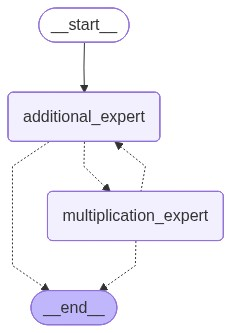

In [59]:
display(Image(app.get_graph().draw_mermaid_png()))

In [60]:

app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", id='7f8e5b76-5d2e-4284-9e46-a75dd7a77cae'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jzrdq99mx', 'function': {'arguments': 'null', 'name': 'transfer_to_multiplication_expert'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 253, 'total_tokens': 266, 'completion_time': 0.024863564, 'completion_tokens_details': None, 'prompt_time': 0.012849181, 'prompt_tokens_details': None, 'queue_time': 0.166358387, 'total_time': 0.037712745}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-0d3e414b-cd9e-45d6-a842-31e111160022-0', tool_calls=[{'name': 'transfer_to_multiplication_expert', 'args': {}, 'id': 'jzrdq99mx', 'type': 'tool_call'}], usage_metadata={'input_tokens': 253, 'output_tokens': 13, 'total_tokens': 266}),
  ToolMessage(content='Successfully tr

In [61]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [62]:
# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
    {"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]},
):
    print("****chunk...****")
    
    pretty_print_messages(chunk)

****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (fh6hwrf7f)
 Call ID: fh6hwrf7f
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_addition_expert (qaz4aek2f)
 Call ID: qaz4aek2f
  Args:
================================= Tool Message =================================

Successfully transferred


****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================

First, calculate the addition: 3 + 5 = 8. Then, ask the multiplication expert for help with 8 * 12.
Tool Calls:
  transfer_to_multiplication_expert (nakbaw9n6)
 Call ID: nakbaw9n6
  Args:
===========

In [63]:

@tool
def transfer_to_travel_advisor():
    """Ask travel advisor for help."""
    return
@tool
def transfer_to_hotel_advisor():
    """Ask hotel advisor for help."""
    return

In [64]:
def travel_advisor(state: MessagesState) -> Command[Literal["hotel_advisor", "__end__"]]:
    system_prompt = (
        "You are a general travel expert that can recommend travel destinations (e.g. countries, cities, etc). "
        "If you need hotel recommendations, ask 'hotel_advisor' for help."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = llm.bind_tools([transfer_to_hotel_advisor]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        
        return Command(goto="hotel_advisor", update={"messages": [ai_msg, tool_msg]})
    
    return {"messages": [ai_msg]}

In [65]:
def hotel_advisor(state: MessagesState) -> Command[Literal["travel_advisor", "__end__"]]:
    system_prompt = (
        "You are a hotel expert that can provide hotel recommendations for a given destination. "
        "If you need help picking travel destinations, ask 'travel_advisor' for help."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([transfer_to_travel_advisor]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="travel_advisor", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [66]:

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("travel_advisor", travel_advisor)
graph_builder.add_node("hotel_advisor", hotel_advisor)

In [67]:

# we'll always start with a general travel advisor
graph_builder.add_edge(START, "travel_advisor")

In [70]:

app = graph_builder.compile()


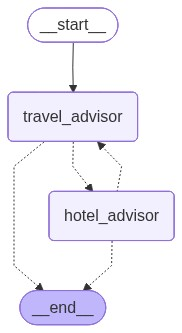

In [71]:
display(Image(app.get_graph().draw_mermaid_png()))

In [72]:
app.invoke({"messages":[("user","I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?")]})

{'messages': [HumanMessage(content='I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?', id='f791653f-7c0b-45d5-9324-295f55b06ee8'),
  AIMessage(content="To travel from Mumbai to California, you have several flight options. You can fly from Chhatrapati Shivaji Maharaj International Airport (BOM) in Mumbai to Los Angeles International Airport (LAX) or San Francisco International Airport (SFO) with airlines such as Air India, United Airlines, or Delta Air Lines, among others. The flight duration is around 17-18 hours, depending on the route and layovers.\n\nFor hotel recommendations, I'll ask the hotel advisor for help.\n\n", additional_kwargs={'tool_calls': [{'id': 'rfep092tc', 'function': {'arguments': 'null', 'name': 'transfer_to_hotel_advisor'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 272, 'total_tokens': 386, 'completion_time': 0.325677573, 'complet

In [73]:
for chunk in app.stream(
    {"messages": [("user", "I am planning a trip to the California in the USA from Mumbai. Can you guide me on travel options and suggest the best hotel?")]},
):
    print("****chunk****")
    
    pretty_print_messages(chunk)

****chunk****
Update from node travel_advisor:


================================== Ai Message ==================================

California is a wonderful destination. To get to California from Mumbai, you have several flight options. You can fly from Chhatrapati Shivaji Maharaj International Airport (BOM) in Mumbai to one of California's major airports such as Los Angeles International Airport (LAX), San Francisco International Airport (SFO), or San Diego International Airport (SAN). Airlines like Air India, United Airlines, and American Airlines offer direct or connecting flights.

Once you arrive in California, you can explore various cities like Los Angeles, San Francisco, San Diego, or Sacramento. Each city has its unique attractions, such as beaches, theme parks, museums, and cultural landmarks.

For hotel recommendations, I'll ask the hotel advisor for help.
Tool Calls:
  transfer_to_hotel_advisor (fvwmhjskf)
 Call ID: fvwmhjskf
  Args:
================================= Tool M